Training Bayesian Neural Network...
Finished Training! Loss: 0.0842 (NLL: 0.0052, KL: 0.0790)

--- In-Distribution (Seen Data) evaluation ---
Point [1.53658231 1.53427025]:
  - Predicted Probabilities: Class 0: 0.2%, Class 1: 99.8%
  - Prediction Agreement Variance (Std Dev): 0.0047
  - Output Entropy (Uncertainty): 0.0119
Point [2.24196227 0.08671976]:
  - Predicted Probabilities: Class 0: 0.6%, Class 1: 99.4%
  - Prediction Agreement Variance (Std Dev): 0.0139
  - Output Entropy (Uncertainty): 0.0386

--- Out-of-Distribution (Anomalies) evaluation ---
Point [ 5. -5.]:
  - Predicted Probabilities: Class 0: 41.0%, Class 1: 59.0%
  - Prediction Agreement Variance (Std Dev): 0.3963
  - Output Entropy (Uncertainty): 0.6770
Point [-5.  5.]:
  - Predicted Probabilities: Class 0: 60.4%, Class 1: 39.6%
  - Prediction Agreement Variance (Std Dev): 0.3825
  - Output Entropy (Uncertainty): 0.6715


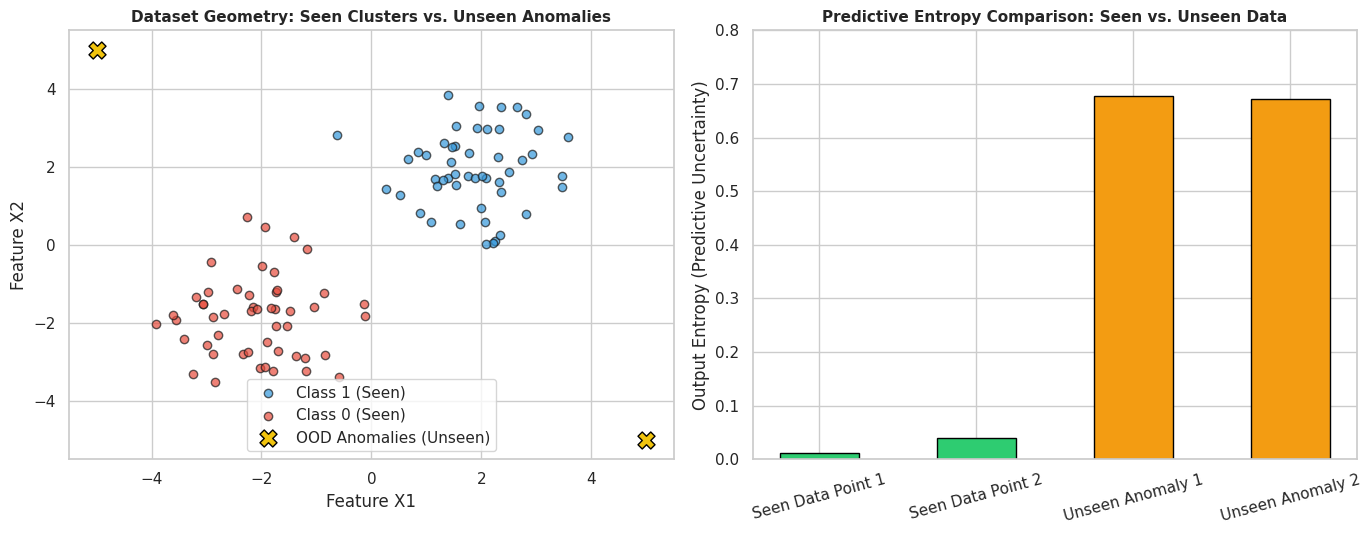

In [ ]:

# ==========================================
# Setup
# ==========================================

import os  # system tools
import warnings  # silence warnings
import numpy as np  # fast math
import torch  # deep learning
import torch.nn as nn  # neural layers
import torch.nn.functional as F  # math functions
import torch.optim as optim  # model trainers
import matplotlib.pyplot as plt  # plot graphs
import seaborn as sns  # plot styling

warnings.filterwarnings('ignore')  # hide warnings

SEED = 42  # standard seed
torch.manual_seed(SEED)  # seed pytorch
np.random.seed(SEED)  # seed numpy

# ==========================================
# Probabilistic Bayesian Linear Layer
# ==========================================

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features  # inputs count
        self.out_features = out_features  # outputs count
        self.prior_sigma = prior_sigma  # gaussian prior

        # Trainable parameters: means (mu) and unconstrained scale parameter (rho)
        self.weight_mu = nn.Parameter(torch.Tensor(out_features, in_features).normal_(0, 0.1)) # Weight Mean: Trainable parameter storing the mean of weight distribution - initialized with small Gaussian (mean=0, std=0.1) for variational inference.
        self.weight_rho = nn.Parameter(torch.Tensor(out_features, in_features).fill_(-1.5)) # Weight Rho: Trainable parameter for log-scale variance (unconstrained) - initialized to -1.5, converted to sigma via softplus for positive standard deviation.
        self.bias_mu = nn.Parameter(torch.Tensor(out_features).normal_(0, 0.1)) # Bias Mean: Trainable parameter storing the mean of bias distribution - initialized with small Gaussian for variational inference.
        self.bias_rho = nn.Parameter(torch.Tensor(out_features).fill_(-1.5)) # Bias Rho: Trainable parameter for log-scale variance (unconstrained) - initialized to -1.5, converted to sigma via softplus for positive standard deviation.
        self.kl_loss = 0.0  # init tracker

    def forward(self, x):
        # Retrieve actual standard deviations from rho using softplus
        weight_sigma = torch.log1p(torch.exp(self.weight_rho)) # Softplus: Converts rho to positive standard deviation using log(1+exp(rho)) - ensures sigma > 0, stable gradient flow.
        bias_sigma = torch.log1p(torch.exp(self.bias_rho))

        # Reparameterization trick: sample random epsilon perturbations
        epsilon_w = torch.randn_like(weight_sigma)
        epsilon_b = torch.randn_like(bias_sigma)

        # Compute active weights out-of-place to preserve gradients
        weight = self.weight_mu + weight_sigma * epsilon_w
        bias = self.bias_mu + bias_sigma * epsilon_b

        # Calculate KL Divergence analytically against Gaussian prior
        kl_w = self.kl_divergence(self.weight_mu, weight_sigma, self.prior_sigma)
        kl_b = self.kl_divergence(self.bias_mu, bias_sigma, self.prior_sigma)
        self.kl_loss = kl_w + kl_b  # save layers sum

        return F.linear(x, weight, bias)  # linear pass

    def kl_divergence(self, mu, sigma, prior_sigma):
        # KL between two Gaussians formula
        return torch.sum(torch.log(prior_sigma / sigma) + (sigma**2 + mu**2) / (2 * prior_sigma**2) - 0.5)

# ==========================================
# Bayesian MLP Network
# ==========================================

class BayesianMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=16, output_dim=2):
        super().__init__()
        self.b_linear1 = BayesianLinear(input_dim, hidden_dim)  # probabilistic hidden
        self.b_linear2 = BayesianLinear(hidden_dim, output_dim)  # probabilistic output

    def forward(self, x):
        x = F.relu(self.b_linear1(x))  # activate layer 1
        x = self.b_linear2(x)  # run layer 2
        return x  # return logits

    def get_kl(self):
        return self.b_linear1.kl_loss + self.b_linear2.kl_loss  # return net KL sum

# ==========================================
# Data Generation (Seen vs Unseen OOD)
# ==========================================

# Create 2D In-Distribution (ID) seen training clusters
X_train = np.random.randn(100, 2)
X_train[:50] += 2.0  # Cluster 1 (Class 1) centered at [3]
X_train[50:] -= 2.0  # Cluster 2 (Class 0) centered at [-2, -2]
y_train = np.array([1]*50 + [0]*50)  # assign cluster labels

# Create Out-of-Distribution (OOD) unseen anomalies (orthogonal to clusters, far away)
X_ood = np.array([[5.0, -5.0], [-5.0, 5.0]])

# Convert train set to PyTorch tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)

# ==========================================
# Train BNN via Variational Inference
# ==========================================

model = BayesianMLP()  # init network
optimizer = optim.Adam(model.parameters(), lr=0.01)  # init adam optimizer
criterion = nn.CrossEntropyLoss()  # loss function

print("Training Bayesian Neural Network...")  # log status
for epoch in range(300):  # training epochs loop
    model.train()  # set training state

    outputs = model(X_train_t)  # forward pass
    nll = criterion(outputs, y_train_t)  # compute classification loss
    kl = model.get_kl() / 1000.0  # scale down complexity cost
    loss = nll + kl  # total ELBO loss

    optimizer.zero_grad()  # clean gradients
    loss.backward()  # backprop
    optimizer.step()  # update parameters

print(f"Finished Training! Loss: {loss.item():.4f} (NLL: {nll.item():.4f}, KL: {kl.item():.4f})")

# ==========================================
# Uncertainty Estimation via Sampling
# ==========================================

model.eval()  # freeze trainable parameters
n_samples = 100  # number of ensemble weight samples to draw

def evaluate_uncertainty(X_eval, name):
    preds = []  # save predictions
    with torch.no_grad():  # freeze gradients
        for _ in range(n_samples):  # sample weight configurations
            logits = model(torch.FloatTensor(X_eval))  # forward pass
            probs = F.softmax(logits, dim=-1).numpy()  # get probabilities
            preds.append(probs)  # append results

    preds = np.stack(preds)  # array dims: (samples, data_points, classes)
    mean_preds = preds.mean(axis=0)  # average probability across ensembles
    std_preds = preds.std(axis=0)  # standard deviation across ensembles
    entropy = -np.sum(mean_preds * np.log(mean_preds + 1e-8), axis=1)  # compute output entropy

    print(f"\n--- {name} evaluation ---")
    for i in range(len(X_eval)):
        print(f"Point {X_eval[i]}:")
        print(f"  - Predicted Probabilities: Class 0: {mean_preds[i, 0]*100:.1f}%, Class 1: {mean_preds[i, 1]*100:.1f}%")
        print(f"  - Prediction Agreement Variance (Std Dev): {std_preds[i, 0]:.4f}")
        print(f"  - Output Entropy (Uncertainty): {entropy[i]:.4f}")

    return mean_preds, std_preds, entropy

# Evaluate seen training points vs unseen anomalies
id_mean, id_std, id_entropy = evaluate_uncertainty(X_train[[5, 6]], "In-Distribution (Seen Data)")
ood_mean, ood_std, ood_entropy = evaluate_uncertainty(X_ood, "Out-of-Distribution (Anomalies)")

# ==========================================
# Visualizations
# ==========================================

sns.set_theme(style="whitegrid")  # set style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))  # canvas layout

# Left plot: Train points and OOD points
ax1.scatter(X_train[:50, 0], X_train[:50, 1], color='#3498db', label='Class 1 (Seen)', alpha=0.7, edgecolors='k')
ax1.scatter(X_train[50:, 0], X_train[50:, 1], color='#e74c3c', label='Class 0 (Seen)', alpha=0.7, edgecolors='k')
ax1.scatter(X_ood[:, 0], X_ood[:, 1], color='#f1c40f', marker='X', s=150, label='OOD Anomalies (Unseen)', edgecolors='black')
ax1.set_title('Dataset Geometry: Seen Clusters vs. Unseen Anomalies', fontsize=11, fontweight='bold')
ax1.set_xlabel('Feature X1')
ax1.set_ylabel('Feature X2')
ax1.legend()

# Right plot: Comparative uncertainty bar chart
categories = ['Seen Data Point 1', 'Seen Data Point 2', 'Unseen Anomaly 1', 'Unseen Anomaly 2']
entropies = [id_entropy[0], id_entropy[1], ood_entropy[0], ood_entropy[1]]
ax2.bar(categories, entropies, color=['#2ecc71', '#2ecc71', '#f39c12', '#f39c12'], width=0.5, edgecolor='black')
ax2.set_ylabel('Output Entropy (Predictive Uncertainty)')
ax2.set_ylim(0, 0.8)  # standard ln(2) limits
ax2.set_title('Predictive Entropy Comparison: Seen vs. Unseen Data', fontsize=11, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()  # draw plots